# 03. Classification metric comparison with XGBoost

**Purpose.** Train compact XGBoost classifiers on scaffold folds and compare no-scaffold test performance with ordinary-fold references.

**Datasets.** Eye corrosion and Micronucleus tox.

**Main outputs.**
- `classification_label_shift_by_scaffold_status.csv`
- `classification_metric_comparison_summary.csv`
- `classification_prior_baseline_view.csv`

**Expected observation.** Metric values can differ between no-scaffold subsets and ordinary-fold references when class priors shift.

**Data source.** `data/demo/scaffold_from_scratch/`

In [1]:

from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem, DataStructs, rdBase
from rdkit.Chem import AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold

import xgboost as xgb

rdBase.BlockLogs()
warnings.filterwarnings("ignore", category=UserWarning)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ROOT = PROJECT_ROOT / "data" / "demo" / "scaffold_from_scratch"
OUT_DIR = PROJECT_ROOT / "outputs" / "notebook_03_classification_metrics"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FP_BITS = 1024
NUM_BOOST_ROUND = 80
SEED = 10086

DATASETS = [
    {
        "name": "eye_corrosion",
        "label": "Eye corrosion",
        "path": DATA_ROOT / "eye_corrosion.csv",
        "target": "eye_corrosion",
    },
    {
        "name": "micronucleus_tox",
        "label": "Micronucleus tox",
        "path": DATA_ROOT / "micronucleus_tox.csv",
        "target": "micronucleus_tox",
    },
]

In [2]:
print(f"Project root: {PROJECT_ROOT.name}")
print(f"Input directory: {DATA_ROOT.relative_to(PROJECT_ROOT)}")
print(f"Output directory: {OUT_DIR.relative_to(PROJECT_ROOT)}")


Project root: empty-scaffold
Input directory: data/demo/scaffold_from_scratch
Output directory: outputs/notebook_03_classification_metrics


## Helper functions

In [3]:

NO_SCAFFOLD_LABELS = {"No_Scaffold"}


def normalize_smiles(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None
    try:
        return Chem.MolToSmiles(Chem.rdmolops.RemoveHs(mol))
    except Exception:
        return None


def murcko_scaffold(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return "Invalid_SMILES"
    try:
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        if scaffold is None or scaffold.GetNumAtoms() == 0:
            return "No_Scaffold"
        return Chem.MolToSmiles(scaffold)
    except Exception:
        return "Error"


def annotate_scaffolds(df, smiles_col="molecules"):
    out = df.copy().reset_index(drop=True)
    out["SMILES_norm"] = out[smiles_col].map(normalize_smiles)
    out = out.dropna(subset=["SMILES_norm"]).reset_index(drop=True)
    out["scaffold"] = out["SMILES_norm"].map(murcko_scaffold)
    out["no_scaffold"] = out["scaffold"].isin(NO_SCAFFOLD_LABELS)
    out["scaffold_group"] = np.where(out["no_scaffold"], "__NO_SCAFFOLD__", out["scaffold"])
    return out


def scaffold_kfolds_for_n(n):
    if n <= 1000:
        return 5
    if n <= 3000:
        return 7
    return 10


def assign_scaffold_folds(df, n_folds, seed=10086):
    out = df.copy().reset_index(drop=True)
    rng = np.random.RandomState(seed)
    groups = []
    for group, idx in out.groupby("scaffold_group", sort=False).groups.items():
        groups.append((str(group), list(idx)))
    if len(groups) < n_folds:
        raise ValueError(f"number of scaffold groups ({len(groups)}) is smaller than n_folds={n_folds}")
    rng.shuffle(groups)
    groups = sorted(groups, key=lambda item: len(item[1]), reverse=True)

    fold_sizes = [0 for _ in range(n_folds)]
    fold_ids = np.empty(len(out), dtype=int)
    for fold, (_, idx) in enumerate(groups[:n_folds]):
        fold_ids[idx] = fold
        fold_sizes[fold] += len(idx)
    for _, idx in groups[n_folds:]:
        min_size = min(fold_sizes)
        candidates = [i for i, size in enumerate(fold_sizes) if size == min_size]
        fold = int(rng.choice(candidates))
        fold_ids[idx] = fold
        fold_sizes[fold] += len(idx)

    perm = np.arange(n_folds)
    rng.shuffle(perm)
    remap = {old: int(new) for old, new in zip(range(n_folds), perm)}
    out["fold"] = np.asarray([remap[int(f)] for f in fold_ids], dtype=int)
    return out


def no_scaffold_fold(folded):
    return int(folded.groupby("fold")["no_scaffold"].sum().idxmax())


def summarize_scaffold_allocation(folded, dataset, target):
    rows = []
    for fold, part in folded.groupby("fold", sort=True):
        rows.append({
            "dataset": dataset,
            "fold": int(fold),
            "n_total": int(len(part)),
            "n_no_scaffold": int(part["no_scaffold"].sum()),
            "no_scaffold_fraction": float(part["no_scaffold"].mean()),
            "n_positive": int(part[target].sum()),
            "positive_rate": float(part[target].mean()),
        })
    return pd.DataFrame(rows)

In [4]:

def mol_to_fp(smiles, n_bits=1024):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None
    try:
        return AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=n_bits)
    except Exception:
        return None


def add_fingerprints(df, n_bits=1024):
    fps = []
    keep = []
    for i, smi in enumerate(df["SMILES_norm"].tolist()):
        fp = mol_to_fp(smi, n_bits=n_bits)
        if fp is not None:
            keep.append(i)
            fps.append(fp)
    out = df.iloc[keep].copy().reset_index(drop=True)
    out["fp"] = fps
    return out


def fps_to_array(fps):
    arr = np.zeros((len(fps), FP_BITS), dtype=np.float32)
    for i, fp in enumerate(fps):
        DataStructs.ConvertToNumpyArray(fp, arr[i])
    return arr


def fit_predict_xgboost(train_df, test_df, target):
    train_df = train_df.dropna(subset=[target]).copy()
    test_df = test_df.dropna(subset=[target]).copy()
    train_df = add_fingerprints(train_df, n_bits=FP_BITS)
    test_df = add_fingerprints(test_df, n_bits=FP_BITS)

    y_train = train_df[target].astype(int).to_numpy()
    y_test = test_df[target].astype(int).to_numpy()
    if len(np.unique(y_train)) < 2:
        raise ValueError("training set has a single class")

    x_train = fps_to_array(train_df["fp"].tolist())
    x_test = fps_to_array(test_df["fp"].tolist())

    n_pos = max(1, int(np.sum(y_train == 1)))
    n_neg = max(1, int(np.sum(y_train == 0)))
    booster = xgb.train(
        {
            "objective": "binary:logistic",
            "eval_metric": "logloss",
            "eta": 0.05,
            "max_depth": 3,
            "subsample": 0.9,
            "colsample_bytree": 0.9,
            "scale_pos_weight": n_neg / n_pos,
            "seed": SEED,
            "nthread": 1,
        },
        xgb.DMatrix(x_train, label=y_train),
        num_boost_round=NUM_BOOST_ROUND,
        verbose_eval=False,
    )

    out = test_df.drop(columns=["fp"]).copy()
    out["y_true"] = y_test
    out["y_score"] = booster.predict(xgb.DMatrix(x_test))
    out["y_pred"] = (out["y_score"] >= 0.5).astype(int)
    return out.reset_index(drop=True)

In [5]:

def finite_pair_arrays(y_true, y_score):
    y_true = np.asarray(y_true, dtype=float)
    y_score = np.asarray(y_score, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_score)
    return y_true[mask], y_score[mask]


def average_precision_grouped(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    n_pos = int(np.sum(y_true == 1))
    if n_pos == 0:
        return float("nan")

    order = np.argsort(-y_score, kind="mergesort")
    y = y_true[order]
    scores = y_score[order]
    group_end = np.r_[np.where(np.diff(scores) != 0)[0], len(scores) - 1]
    tp_cum = np.cumsum(y == 1)[group_end]
    fp_cum = (group_end + 1) - tp_cum
    precision = tp_cum / np.maximum(tp_cum + fp_cum, 1)
    recall = tp_cum / n_pos
    recall_prev = np.r_[0.0, recall[:-1]]
    return float(np.sum((recall - recall_prev) * precision))


def average_ranks(values):
    values = np.asarray(values, dtype=float)
    order = np.argsort(values, kind="mergesort")
    ranks = np.empty(len(values), dtype=float)
    i = 0
    while i < len(values):
        j = i + 1
        while j < len(values) and values[order[j]] == values[order[i]]:
            j += 1
        avg_rank = (i + 1 + j) / 2.0
        ranks[order[i:j]] = avg_rank
        i = j
    return ranks


def roc_auc_rank(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    n_pos = int(np.sum(y_true == 1))
    n_neg = int(np.sum(y_true == 0))
    if n_pos == 0 or n_neg == 0:
        return float("nan")
    ranks = average_ranks(y_score)
    sum_pos = float(np.sum(ranks[y_true == 1]))
    return float((sum_pos - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg))


def threshold_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    if len(y_true) == 0:
        return {"accuracy": float("nan"), "balanced_accuracy": float("nan"), "f1": float("nan"), "mcc": float("nan")}

    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))

    accuracy = (tp + tn) / len(y_true)
    sensitivity = tp / (tp + fn) if (tp + fn) else float("nan")
    specificity = tn / (tn + fp) if (tn + fp) else float("nan")
    balanced_accuracy = np.nanmean([sensitivity, specificity])
    f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) else float("nan")
    denom = float((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    mcc = ((tp * tn - fp * fn) / math.sqrt(denom)) if denom > 0 else float("nan")
    return {
        "accuracy": float(accuracy),
        "balanced_accuracy": float(balanced_accuracy),
        "f1": float(f1),
        "mcc": float(mcc),
    }


def norm_pr(y_true, y_score):
    y_true, y_score = finite_pair_arrays(y_true, y_score)
    if len(y_true) == 0 or len(np.unique(y_true.astype(int))) < 2:
        return float("nan")
    y_true = y_true.astype(int)
    positive_rate = float(np.mean(y_true == 1))
    if positive_rate >= 1.0:
        return float("nan")
    ap = average_precision_grouped(y_true, y_score)
    return float((ap - positive_rate) / (1.0 - positive_rate))


def classification_metrics(y_true, y_score, y_pred):
    y_true, y_score = finite_pair_arrays(y_true, y_score)
    y_pred = np.asarray(y_pred)[np.isfinite(np.asarray(y_score, dtype=float))]
    out = {
        "n": int(len(y_true)),
        "n_positive": int(np.sum(y_true == 1)) if len(y_true) else 0,
        "n_negative": int(np.sum(y_true == 0)) if len(y_true) else 0,
        "positive_rate": float(np.mean(y_true == 1)) if len(y_true) else float("nan"),
        "average_precision": float("nan"),
        "roc_auc": float("nan"),
        "normPR": float("nan"),
        "accuracy": float("nan"),
        "balanced_accuracy": float("nan"),
        "f1": float("nan"),
        "mcc": float("nan"),
    }
    if len(y_true):
        y_true_i = y_true.astype(int)
        out.update(threshold_metrics(y_true_i, y_pred.astype(int)))
        if len(np.unique(y_true_i)) >= 2:
            out["average_precision"] = average_precision_grouped(y_true_i, y_score)
            out["roc_auc"] = roc_auc_rank(y_true_i, y_score)
            out["normPR"] = norm_pr(y_true_i, y_score)
    return out

## Rebuild scaffold folds and inspect label shifts

In [6]:

folded_tables = {}
allocation_rows = []
label_shift_rows = []

for spec in DATASETS:
    raw = pd.read_csv(spec["path"])
    raw = raw.dropna(subset=[spec["target"]]).reset_index(drop=True)
    raw = raw.loc[raw[spec["target"]].isin([0, 1])].reset_index(drop=True)
    annotated = annotate_scaffolds(raw, smiles_col="molecules")
    n_folds = scaffold_kfolds_for_n(len(annotated))
    folded = assign_scaffold_folds(annotated, n_folds=n_folds)
    folded_tables[spec["name"]] = folded

    allocation_rows.append(summarize_scaffold_allocation(folded, spec["name"], spec["target"]))
    for status, part in [("no_scaffold", folded.loc[folded["no_scaffold"]]), ("scaffold_bearing", folded.loc[~folded["no_scaffold"]])]:
        label_shift_rows.append({
            "dataset": spec["name"],
            "subset": status,
            "n": int(len(part)),
            "n_positive": int(part[spec["target"]].sum()),
            "positive_rate": float(part[spec["target"]].mean()),
        })

allocation = pd.concat(allocation_rows, ignore_index=True)
label_shift = pd.DataFrame(label_shift_rows)

allocation.to_csv(OUT_DIR / "classification_scaffold_fold_allocation.csv", index=False)
label_shift.to_csv(OUT_DIR / "classification_label_shift_by_scaffold_status.csv", index=False)

display(label_shift)
display(allocation)

,dataset,subset,n,n_positive,positive_rate
0,eye_corrosion,no_scaffold,553,478,0.864376
1,eye_corrosion,scaffold_bearing,1745,407,0.233238
2,micronucleus_tox,no_scaffold,233,43,0.184549
3,micronucleus_tox,scaffold_bearing,408,221,0.541667


,dataset,fold,n_total,n_no_scaffold,no_scaffold_fraction,n_positive,positive_rate
0,eye_corrosion,0,273,0,0.0,36,0.131868
1,eye_corrosion,1,273,0,0.0,34,0.124542
2,eye_corrosion,2,274,0,0.0,49,0.178832
3,eye_corrosion,3,274,0,0.0,25,0.091241
4,eye_corrosion,4,378,0,0.0,242,0.640212
5,eye_corrosion,5,553,553,1.0,478,0.864376
6,eye_corrosion,6,273,0,0.0,21,0.076923
7,micronucleus_tox,0,102,0,0.0,50,0.490196
8,micronucleus_tox,1,102,0,0.0,43,0.421569
9,micronucleus_tox,2,233,233,1.0,43,0.184549


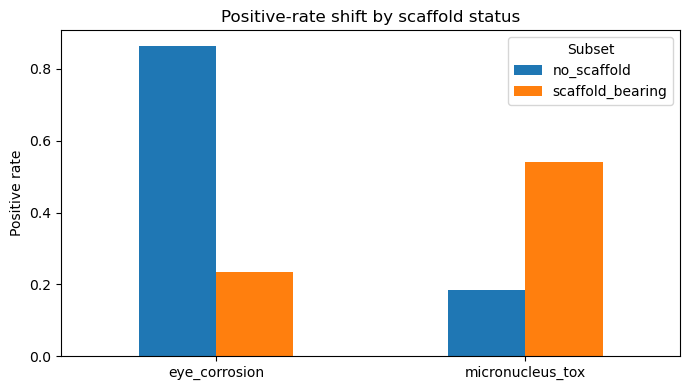

In [7]:

fig, ax = plt.subplots(figsize=(7, 4))
plot_df = label_shift.pivot(index="dataset", columns="subset", values="positive_rate")
plot_df.plot(kind="bar", ax=ax)
ax.set_ylabel("Positive rate")
ax.set_xlabel("")
ax.set_title("Positive-rate shift by scaffold status")
ax.legend(title="Subset")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Train XGBoost across scaffold folds

The fold containing the no-scaffold bucket is evaluated as the no-scaffold fold; the other folds provide the ordinary-fold reference.

In [8]:

prediction_tables = []
metric_rows = []

for spec in DATASETS:
    folded = folded_tables[spec["name"]]
    ns_fold = no_scaffold_fold(folded)

    for fold in sorted(folded["fold"].unique()):
        train_df = folded.loc[folded["fold"] != fold].copy().reset_index(drop=True)
        test_df = folded.loc[folded["fold"] == fold].copy().reset_index(drop=True)

        predictions = fit_predict_xgboost(train_df, test_df, spec["target"])
        predictions["dataset"] = spec["name"]
        predictions["eval_fold"] = int(fold)
        predictions["no_scaffold_fold"] = int(ns_fold)
        prediction_tables.append(predictions)

        if fold == ns_fold:
            subsets = [("no_scaffold_test", predictions.loc[predictions["no_scaffold"]])]
        else:
            subsets = [("ordinary_test", predictions)]

        for subset_name, subset_df in subsets:
            metrics = classification_metrics(subset_df["y_true"], subset_df["y_score"], subset_df["y_pred"])
            metrics.update({
                "dataset": spec["name"],
                "subset": subset_name,
                "eval_fold": int(fold),
                "no_scaffold_fold": int(ns_fold),
            })
            metric_rows.append(metrics)

predictions_all = pd.concat(prediction_tables, ignore_index=True)
metrics_by_fold = pd.DataFrame(metric_rows)

predictions_all.to_csv(OUT_DIR / "classification_xgboost_predictions.csv", index=False)
metrics_by_fold.to_csv(OUT_DIR / "classification_metrics_by_fold.csv", index=False)

display(metrics_by_fold)

[11:42:52] DEPRECATION WARNING: please use MorganGenerator
[11:42:52] DEPRECATION WARNING: please use MorganGenerator
[11:42:52] DEPRECATION WARNING: please use MorganGenerator
[11:42:52] DEPRECATION WARNING: please use MorganGenerator
[11:42:52] DEPRECATION WARNING: please use MorganGenerator
[11:42:52] DEPRECATION WARNING: please use MorganGenerator
[11:42:52] DEPRECATION WARNING: please use MorganGenerator
[11:42:52] DEPRECATION WARNING: please use MorganGenerator
[11:42:52] DEPRECATION WARNING: please use MorganGenerator
[11:42:52] DEPRECATION WARNING: please use MorganGenerator
[11:42:52] DEPRECATION WARNING: please use MorganGenerator
[11:42:52] DEPRECATION WARNING: please use MorganGenerator
[11:42:52] DEPRECATION WARNING: please use MorganGenerator
[11:42:52] DEPRECATION WARNING: please use MorganGenerator
[11:42:52] DEPRECATION WARNING: please use MorganGenerator
[11:42:52] DEPRECATION WARNING: please use MorganGenerator
[11:42:52] DEPRECATION WARNING: please use MorganGenerat

,n,n_positive,n_negative,positive_rate,average_precision,roc_auc,normPR,accuracy,balanced_accuracy,f1,mcc,dataset,subset,eval_fold,no_scaffold_fold
0,273,36,237,0.131868,0.932157,0.984060,0.921852,0.937729,0.952356,0.804598,0.785370,eye_corrosion,ordinary_test,0,5
1,273,34,239,0.124542,0.765789,0.943884,0.732470,0.908425,0.846788,0.675325,0.628687,eye_corrosion,ordinary_test,1,5
2,274,49,225,0.178832,0.881298,0.951020,0.855447,0.923358,0.873515,0.787879,0.741170,eye_corrosion,ordinary_test,2,5
3,274,25,249,0.091241,0.803074,0.950522,0.783303,0.941606,0.841928,0.692308,0.660699,eye_corrosion,ordinary_test,3,5
4,378,242,136,0.640212,0.930356,0.890374,0.806430,0.574074,0.665745,0.504615,0.384324,eye_corrosion,ordinary_test,4,5
5,553,478,75,0.864376,0.896389,0.615941,0.236040,0.707052,0.571994,0.817156,0.112088,eye_corrosion,no_scaffold_test,5,5
6,273,21,252,0.076923,0.691887,0.949735,0.666211,0.893773,0.811508,0.508475,0.479605,eye_corrosion,ordinary_test,6,5
7,102,50,52,0.490196,0.866284,0.853846,0.737710,0.549020,0.557308,0.680556,0.213118,micronucleus_tox,ordinary_test,0,2
8,102,43,59,0.421569,0.803028,0.843122,0.659472,0.784314,0.788333,0.760870,0.569965,micronucleus_tox,ordinary_test,1,2
9,233,43,190,0.184549,0.618817,0.855202,0.532549,0.836910,0.558140,0.208333,0.311286,micronucleus_tox,no_scaffold_test,2,2


## No-scaffold subset vs ordinary-fold reference

In [9]:

metric_cols = [
    "positive_rate",
    "average_precision",
    "roc_auc",
    "normPR",
    "accuracy",
    "balanced_accuracy",
    "f1",
    "mcc",
]

summary_rows = []
for dataset, part in metrics_by_fold.groupby("dataset", sort=False):
    ns_row = part.loc[part["subset"] == "no_scaffold_test"].iloc[0]
    ordinary = part.loc[part["subset"] == "ordinary_test"]
    out = {
        "dataset": dataset,
        "n_no_scaffold_test": int(ns_row["n"]),
        "n_positive_no_scaffold_test": int(ns_row["n_positive"]),
        "n_negative_no_scaffold_test": int(ns_row["n_negative"]),
    }
    for metric in metric_cols:
        ordinary_median = float(ordinary[metric].median())
        ns_value = float(ns_row[metric])
        out[f"ordinary_median_{metric}"] = ordinary_median
        out[f"no_scaffold_{metric}"] = ns_value
        out[f"delta_{metric}"] = ns_value - ordinary_median
    summary_rows.append(out)

comparison_summary = pd.DataFrame(summary_rows)
comparison_summary.to_csv(OUT_DIR / "classification_metric_comparison_summary.csv", index=False)
display(comparison_summary)

,dataset,n_no_scaffold_test,n_positive_no_scaffold_test,n_negative_no_scaffold_test,ordinary_median_positive_rate,no_scaffold_positive_rate,delta_positive_rate,ordinary_median_average_precision,no_scaffold_average_precision,delta_average_precision,...,delta_accuracy,ordinary_median_balanced_accuracy,no_scaffold_balanced_accuracy,delta_balanced_accuracy,ordinary_median_f1,no_scaffold_f1,delta_f1,ordinary_median_mcc,no_scaffold_mcc,delta_mcc
0,eye_corrosion,553,478,75,0.128205,0.864376,0.736171,0.842186,0.896389,0.054203,...,-0.208839,0.844358,0.571994,-0.272363,0.683816,0.817156,0.133340,0.644693,0.112088,-0.532605
1,micronucleus_tox,233,43,190,0.544118,0.184549,-0.359568,0.870869,0.618817,-0.252053,...,0.077106,0.747525,0.558140,-0.189385,0.777381,0.208333,-0.569048,0.503411,0.311286,-0.192125


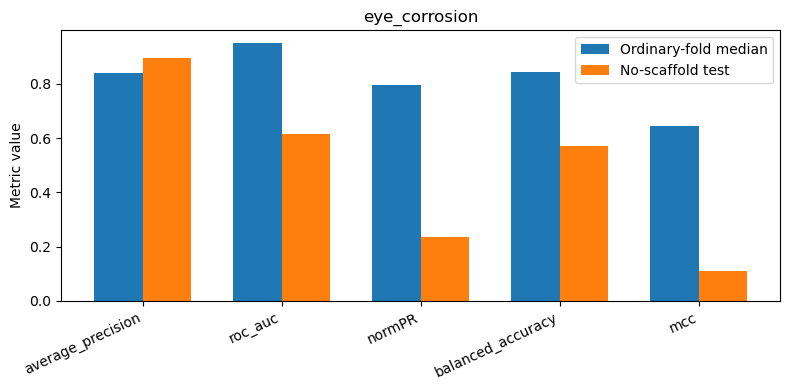

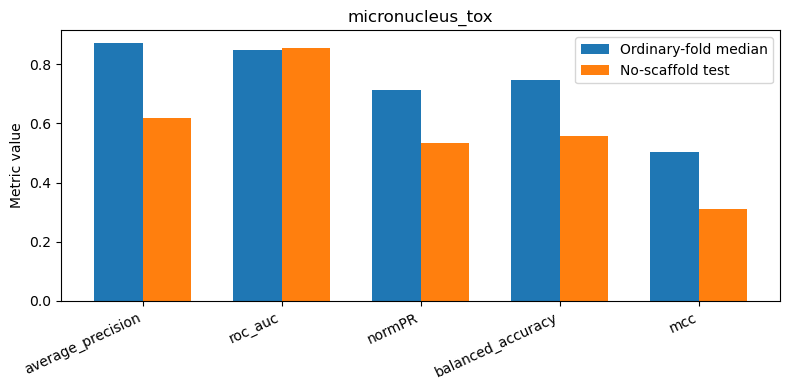

In [10]:

plot_metrics = ["average_precision", "roc_auc", "normPR", "balanced_accuracy", "mcc"]
rows = []
for _, row in comparison_summary.iterrows():
    for metric in plot_metrics:
        rows.append({
            "dataset": row["dataset"],
            "metric": metric,
            "ordinary_median": row[f"ordinary_median_{metric}"],
            "no_scaffold": row[f"no_scaffold_{metric}"],
        })
plot_metrics_df = pd.DataFrame(rows)

for dataset, part in plot_metrics_df.groupby("dataset", sort=False):
    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(part))
    width = 0.35
    ax.bar(x - width / 2, part["ordinary_median"], width, label="Ordinary-fold median")
    ax.bar(x + width / 2, part["no_scaffold"], width, label="No-scaffold test")
    ax.set_xticks(x)
    ax.set_xticklabels(part["metric"], rotation=25, ha="right")
    ax.set_ylabel("Metric value")
    ax.set_title(dataset)
    ax.legend()
    plt.tight_layout()
    plt.show()

## Prior-baseline view

This view compares AP with the positive-rate baseline used to compute normPR.

In [11]:

baseline_rows = []
for _, row in comparison_summary.iterrows():
    dataset = row["dataset"]
    for subset in ["ordinary", "no_scaffold"]:
        prefix = "ordinary_median" if subset == "ordinary" else "no_scaffold"
        baseline_rows.append({
            "dataset": dataset,
            "subset": subset,
            "positive_rate_baseline": row[f"{prefix}_positive_rate"],
            "average_precision": row[f"{prefix}_average_precision"],
            "normPR": row[f"{prefix}_normPR"],
        })

baseline_view = pd.DataFrame(baseline_rows)
baseline_view.to_csv(OUT_DIR / "classification_prior_baseline_view.csv", index=False)
display(baseline_view)

,dataset,subset,positive_rate_baseline,average_precision,normPR
0,eye_corrosion,ordinary,0.128205,0.842186,0.794866
1,eye_corrosion,no_scaffold,0.864376,0.896389,0.236040
2,micronucleus_tox,ordinary,0.544118,0.870869,0.713934
3,micronucleus_tox,no_scaffold,0.184549,0.618817,0.532549


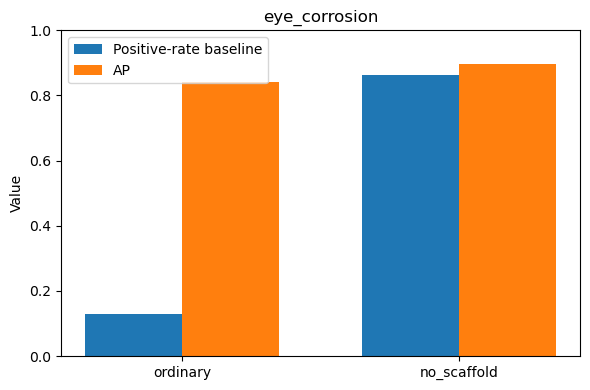

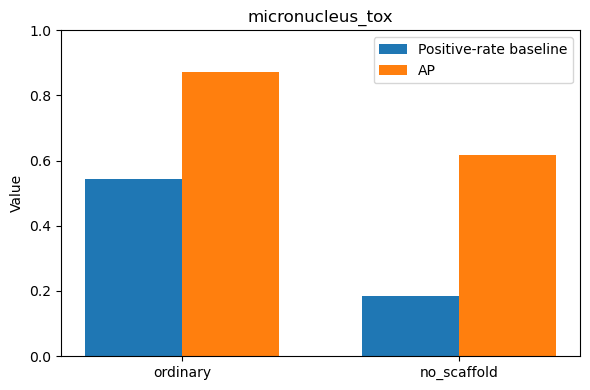

In [12]:

for dataset, part in baseline_view.groupby("dataset", sort=False):
    fig, ax = plt.subplots(figsize=(6, 4))
    x = np.arange(len(part))
    width = 0.35
    ax.bar(x - width / 2, part["positive_rate_baseline"], width, label="Positive-rate baseline")
    ax.bar(x + width / 2, part["average_precision"], width, label="AP")
    ax.set_xticks(x)
    ax.set_xticklabels(part["subset"])
    ax.set_ylim(0, 1)
    ax.set_ylabel("Value")
    ax.set_title(dataset)
    ax.legend()
    plt.tight_layout()
    plt.show()

## Generated files

CSV outputs are written under `outputs/notebook_03_classification_metrics/`.

In [13]:

for path in sorted(OUT_DIR.glob("*.csv")):
    print(path.relative_to(PROJECT_ROOT))

outputs/notebook_03_classification_metrics/classification_label_shift_by_scaffold_status.csv
outputs/notebook_03_classification_metrics/classification_metric_comparison_summary.csv
outputs/notebook_03_classification_metrics/classification_metrics_by_fold.csv
outputs/notebook_03_classification_metrics/classification_prior_baseline_view.csv
outputs/notebook_03_classification_metrics/classification_scaffold_fold_allocation.csv
outputs/notebook_03_classification_metrics/classification_xgboost_predictions.csv
